In [1]:
# Except for the graph plots, to see all the variables output, please use print()

In [2]:
# Load the dataset
from sklearn.datasets import load_breast_cancer

x, y = load_breast_cancer(return_X_y=True)

In [3]:
# Partition the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [4]:
# Do the Scaling
from sklearn import preprocessing

my_scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = my_scaler.transform(X_train)
X_test_scaled = my_scaler.transform(X_test)

In [5]:
# Do the training and get the prediction (KNN)
from sklearn.neighbors import KNeighborsClassifier
model_KNN = KNeighborsClassifier(n_neighbors=5)
model_KNN = model_KNN.fit(X_train_scaled, y_train)
y_pred_KNN = model_KNN.predict(X_test_scaled)

In [6]:
# Do the training and get the prediction (Decision Tree)
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier()
model_DT = model_DT.fit(X_train_scaled, y_train)
y_pred_DT = model_DT.predict(X_test_scaled)

In [7]:
# Do the training and get the prediction (Random Forest)
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier(n_estimators=100)
model_RF = model_RF.fit(X_train_scaled, y_train)
y_pred_RF = model_RF.predict(X_test_scaled)

In [8]:
# Evaluate based on accuracy
from sklearn.metrics import accuracy_score

accuracy_score_KNN = accuracy_score(y_test, y_pred_KNN)
accuracy_score_DT = accuracy_score(y_test, y_pred_DT)
accuracy_score_RF = accuracy_score(y_test, y_pred_RF)

In [9]:
# Evaluate based on precision
from sklearn.metrics import precision_score

precision_score_KNN = precision_score(y_test, y_pred_KNN)
precision_score_DT = precision_score(y_test, y_pred_DT)
precision_score_RF = precision_score(y_test, y_pred_RF)

In [10]:
# Evaluate based on recall
from sklearn.metrics import recall_score

recall_score_KNN = recall_score(y_test, y_pred_KNN)
recall_score_DT = recall_score(y_test, y_pred_DT)
recall_score_RF = recall_score(y_test, y_pred_RF)

In [11]:
# Evaluate based on F1-score
from sklearn.metrics import f1_score

f1_score_KNN = f1_score(y_test, y_pred_KNN)
f1_score_DT = f1_score(y_test, y_pred_DT)
f1_score_RF = f1_score(y_test, y_pred_RF)

In [12]:
# Create confusion matrix for each model
from sklearn.metrics import confusion_matrix

confusion_matrix_KNN = confusion_matrix(y_test, y_pred_KNN)
confusion_matrix_DT = confusion_matrix(y_test, y_pred_DT)
confusion_matrix_RF = confusion_matrix(y_test, y_pred_RF)

Text(0.5, 1.0, 'KNN Classifier - Confusion Matrix')

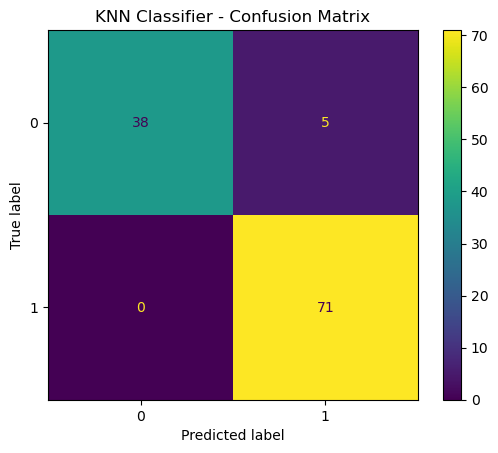

In [13]:
# Dispaly confusion matrix for KNN model
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confusion_matrix_KNN_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_KNN)
confusion_matrix_KNN_display.plot()
plt.title("KNN Classifier - Confusion Matrix")

Text(0.5, 1.0, 'Decision Trees (DT) Classifier - Confusion Matrix')

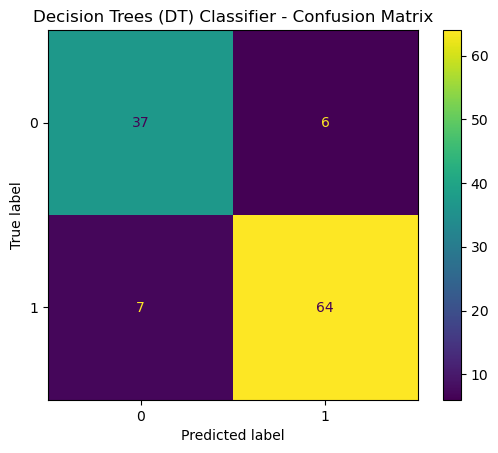

In [14]:
# Dispaly confusion matrix for DT model
confusion_matrix_DT_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_DT)
confusion_matrix_DT_display.plot()
plt.title("Decision Trees (DT) Classifier - Confusion Matrix")

Text(0.5, 1.0, 'Random Forest (RF) Classifier - Confusion Matrix')

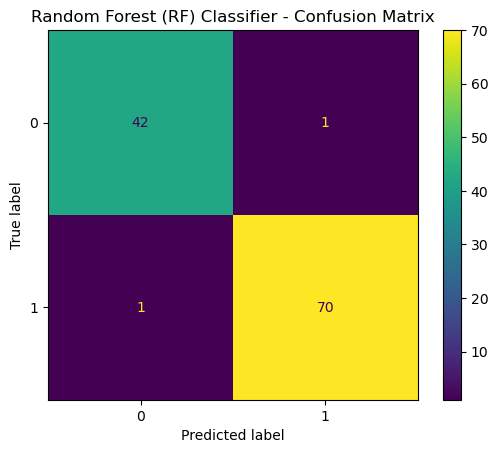

In [15]:
# Dispaly confusion matrix for RF model
confusion_matrix_RF_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_RF)
confusion_matrix_RF_display.plot()
plt.title("Random Forest (RF) Classifier - Confusion Matrix")

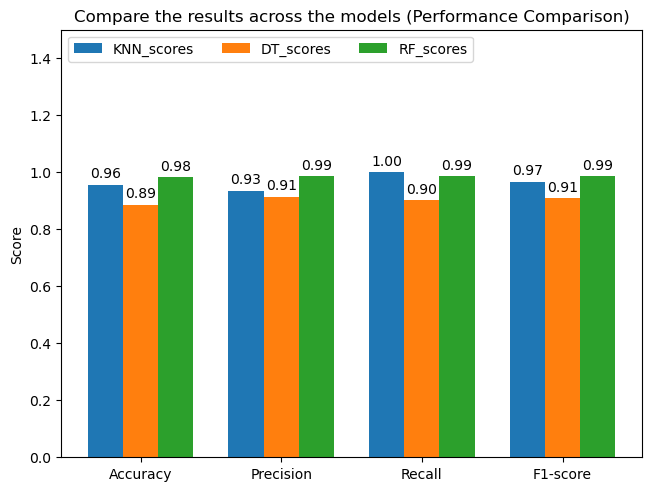

In [16]:
# Compare the results across the models in a graphical format
import numpy as np


metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
scores = {
    "KNN_scores": [accuracy_score_KNN, precision_score_KNN, recall_score_KNN, f1_score_KNN],
    "DT_scores": [accuracy_score_DT, precision_score_DT, recall_score_DT, f1_score_DT],
    "RF_scores": [accuracy_score_RF, precision_score_RF, recall_score_RF, f1_score_RF]
}

width = 0.25
i = 0
x_location = np.arange(len(metrics))

fig, ax = plt.subplots(layout='constrained')

for type, score_list in scores.items():
    bar = ax.bar(x_location + width * i, score_list, width, label=type)
    ax.bar_label(bar, padding = 3, labels=[f'{m:.2f}' for m in score_list])
    i += 1

# Set the range of y axis to 1.5 to keep space for the legend
ax.set_xticks(x_location + width, metrics)
ax.set_ylim(0, 1.5)
ax.legend(loc='upper left', ncols=3)
ax.set_ylabel('Score')
ax.set_title("Compare the results across the models (Performance Comparison)")


plt.show()

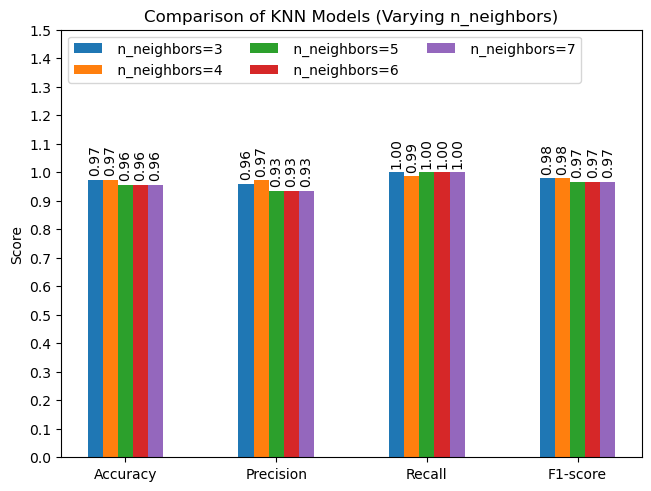

In [17]:
# Modify key hyperparameters, set n_neighbors = 3 to 7 for KNN
from matplotlib.ticker import MultipleLocator

accuracy_score_KNN_modified = []
precision_score_KNN_modified = []
recall_score_KNN_modified = []
f1_score_KNN_modified = []
confusion_matrix_KNN_modified = []

for i in range(3, 8):
    model_KNN_modified = KNeighborsClassifier(n_neighbors=i)
    model_KNN_modified = model_KNN_modified.fit(X_train_scaled, y_train)
    y_pred_KNN_modified_i = model_KNN_modified.predict(X_test_scaled)
    accuracy_score_KNN_modified.append(accuracy_score(y_test, y_pred_KNN_modified_i))
    precision_score_KNN_modified.append(precision_score(y_test, y_pred_KNN_modified_i))
    recall_score_KNN_modified.append(recall_score(y_test, y_pred_KNN_modified_i))
    f1_score_KNN_modified.append(f1_score(y_test, y_pred_KNN_modified_i))
    confusion_matrix_KNN_modified.append(confusion_matrix(y_test, y_pred_KNN_modified_i))


width = 0.1
j = 0
x_location = np.arange(len(metrics))

fig, ax = plt.subplots(layout='constrained')

for j, i in enumerate(range(3, 8)):
    score_list = [accuracy_score_KNN_modified[j], precision_score_KNN_modified[j], recall_score_KNN_modified[j], f1_score_KNN_modified[j]]
    bar = ax.bar(x_location + width * j, score_list, width, label= f' n_neighbors={i}')
    ax.bar_label(bar, padding = 3, labels=[f'{m:.2f}' for m in score_list], rotation=90)

# Set the range of y axis to 1.5 to keep space for the legend
ax.set_xticks(x_location + width * 2, metrics)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylim(0, 1.5)
ax.legend(loc='upper left', ncols=3)
ax.set_ylabel('Score')
ax.set_title("Comparison of KNN Models (Varying n_neighbors)")


plt.show()

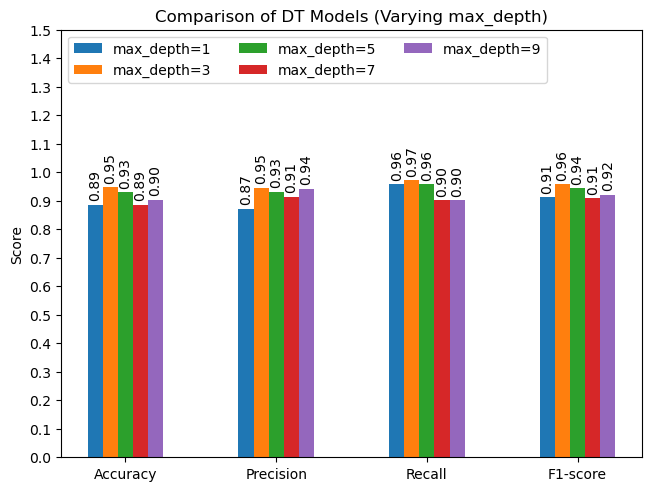

In [18]:
# Modify key hyperparameters, set max_depth = 1, 3, 5, 7, 9 for Decision Trees
accuracy_score_DT_modified = []
precision_score_DT_modified = []
recall_score_DT_modified = []
f1_score_DT_modified = []
confusion_matrix_DT_modified = []

for i in range(1, 10, 2):
    model_DT_modified = DecisionTreeClassifier(max_depth=i)
    model_DT_modified = model_DT_modified.fit(X_train_scaled, y_train)
    y_pred_DT_modified_i = model_DT_modified.predict(X_test_scaled)
    accuracy_score_DT_modified.append(accuracy_score(y_test, y_pred_DT_modified_i))
    precision_score_DT_modified.append(precision_score(y_test, y_pred_DT_modified_i))
    recall_score_DT_modified.append(recall_score(y_test, y_pred_DT_modified_i))
    f1_score_DT_modified.append(f1_score(y_test, y_pred_DT_modified_i))
    confusion_matrix_DT_modified.append(confusion_matrix(y_test, y_pred_DT_modified_i))


width = 0.1
j = 0
x_location = np.arange(len(metrics))

fig, ax = plt.subplots(layout='constrained')

for j, i in enumerate(range(1, 10, 2)):
    score_list = [accuracy_score_DT_modified[j], precision_score_DT_modified[j], recall_score_DT_modified[j], f1_score_DT_modified[j]]
    bar = ax.bar(x_location + width * j, score_list, width, label= f'max_depth={i}')
    ax.bar_label(bar, padding = 3, labels=[f'{m:.2f}' for m in score_list], rotation=90)

# Set the range of y axis to 1.5 to keep space for the legend
ax.set_xticks(x_location + width * 2, metrics)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylim(0, 1.5)
ax.legend(loc='upper left', ncols=3)
ax.set_ylabel('Score')
ax.set_title("Comparison of DT Models (Varying max_depth)")


plt.show()

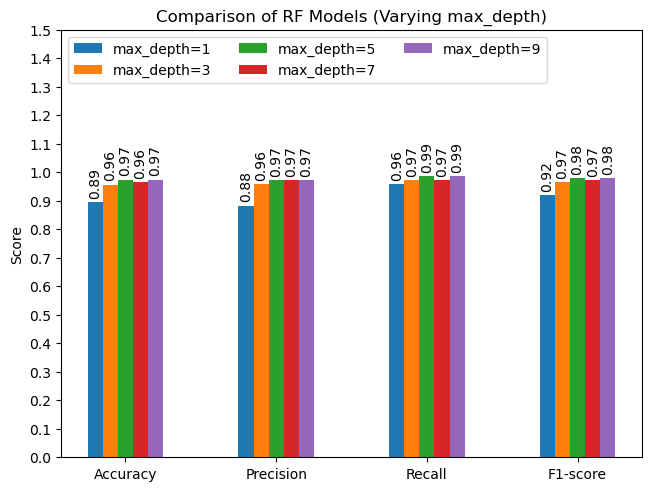

In [19]:
# Modify key hyperparameters, set max_depth = 1, 3, 5, 7, 9 for Random Forest
from matplotlib.ticker import MultipleLocator

accuracy_score_RF_modified = []
precision_score_RF_modified = []
recall_score_RF_modified = []
f1_score_RF_modified = []
confusion_matrix_RF_modified = []

for i in range(1, 10, 2):
    model_RF_modified = RandomForestClassifier(n_estimators=100, max_depth=i)
    model_RF_modified = model_RF_modified.fit(X_train_scaled, y_train)
    y_pred_RF_modified_i = model_RF_modified.predict(X_test_scaled)
    accuracy_score_RF_modified.append(accuracy_score(y_test, y_pred_RF_modified_i))
    precision_score_RF_modified.append(precision_score(y_test, y_pred_RF_modified_i))
    recall_score_RF_modified.append(recall_score(y_test, y_pred_RF_modified_i))
    f1_score_RF_modified.append(f1_score(y_test, y_pred_RF_modified_i))
    confusion_matrix_RF_modified.append(confusion_matrix(y_test, y_pred_RF_modified_i))


width = 0.1
j = 0
x_location = np.arange(len(metrics))

fig, ax = plt.subplots(layout='constrained')

for j, i in enumerate(range(1, 10, 2)):
    score_list = [accuracy_score_RF_modified[j], precision_score_RF_modified[j], recall_score_RF_modified[j], f1_score_RF_modified[j]]
    bar = ax.bar(x_location + width * j, score_list, width, label= f'max_depth={i}')
    ax.bar_label(bar, padding = 3, labels=[f'{m:.2f}' for m in score_list], rotation=90)

# Set the range of y axis to 1.5 to keep space for the legend
ax.set_xticks(x_location + width * 2, metrics)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylim(0, 1.5)
ax.legend(loc='upper left', ncols=3)
ax.set_ylabel('Score')
ax.set_title("Comparison of RF Models (Varying max_depth)")


plt.show()